<a href="https://colab.research.google.com/github/pengel13/Desafio2-IAML/blob/main/desafio2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import keras
from keras.callbacks import ModelCheckpoint
from keras.utils import to_categorical
import pandas as pd
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt

In [7]:
zip_file_path = '/content/dataset.zip'
extract_dir = 'louisiana_images'

In [8]:
train_df = pd.read_csv(extract_dir + '/train.csv')
test_df = pd.read_csv(extract_dir + '/test.csv')

In [ ]:
import tensorflow as tf
import os

image_size = (512, 360)
batch_size = 32

def preprocess_image_py(image_path_tensor, label):
    image_path = image_path_tensor.numpy().decode('utf-8')
    try:
        img = tf.io.read_file(image_path)
        img = tf.image.decode_image(img, channels=3)
        if img.shape.rank == 0:  # Verifica se a imagem está vazia
            raise ValueError(f"imagem vazia")
        img = tf.image.resize(img, image_size)
        img = tf.cast(img, tf.float32) / 255.0  # Normaliza para o intervalo [0, 1]
        return img, label
    except Exception as e:
        print(f"Erro ao processar a imagem {image_path}: {e}")
        # Retorna uma imagem preta preenchida com zeros como substituta
        return tf.zeros((*image_size, 3), dtype=tf.float32), label

def preprocess_image(image_path, label):
    processed_image, processed_label = tf.py_function(
        preprocess_image_py,
        inp=[image_path, label],
        Tout=[tf.float32, label.dtype]
    )
    processed_image.set_shape([*image_size, 3])
    processed_label.set_shape([])
    return processed_image, processed_label

# --- Criar Dataset de Treino ---
print("Criando dataset de treino...")
train_image_filenames = train_df['Image ID'].values
train_labels = train_df['Flooded'].values

train_image_paths = [os.path.join(extract_dir, 'train', fname) for fname in train_image_filenames]

train_dataset = tf.data.Dataset.from_tensor_slices((train_image_paths, train_labels))

train_dataset = train_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=len(train_image_paths)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# --- Criar Dataset de Teste ---
print("Criando dataset de teste...")
test_image_filenames = test_df['Image ID'].values
test_labels = test_df['Flooded'].values

test_image_paths = [os.path.join(extract_dir, 'test', fname) for fname in test_image_filenames]

test_dataset = tf.data.Dataset.from_tensor_slices((test_image_paths, test_labels))
test_dataset = test_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE) # Não embaralha o conjunto de teste

print("Datasets de treino e teste criados com sucesso.")
print(f"Número de amostras de treino: {len(train_image_paths)}")
print(f"Número de amostras de teste: {len(test_image_paths)}")

# Opcional: Verificar um batch do dataset de treino
for images, labels in train_dataset.take(1):
    print(f"Formato do batch de imagens de treino: {images.shape}")
    print(f"Formato do batch de labels de treino: {labels.shape}")
    print(f"Tipo de dados do batch de imagens de treino: {images.dtype}")
    print(f"Tipo de dados do batch de labels de treino: {labels.dtype}")
    break


In [ ]:
from keras.applications import EfficientNetB4
from keras.models import Model
from keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from keras.optimizers import Adam

# Definindo o formato de entrada explicitamente com base no pré-processamento
input_shape = (512, 360, 3)

print("Carregando o modelo EfficientNetB4 com pesos imagenet...")
base_model = EfficientNetB4(
    include_top=False,
    weights='imagenet',
    input_shape=input_shape
)

print("Modelo base EfficientNetB4 carregado com sucesso.")

# Congelar as camadas do modelo base para não serem treinadas
base_model.trainable = False
print("Camadas do modelo base congeladas.")

# Adiciona camadas para classificação binária
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x) # Camada para reduzir overfitting

output_layer = Dense(1, activation='sigmoid')(x)

# Cria o modelo final
model = Model(inputs=base_model.input, outputs=output_layer)

# Compila o modelo
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Exibe o resumo do modelo
model.summary()

print("Modelo de Transfer Learning criado e compilado com sucesso!")

In [ ]:
# cria um checkpoint para salvar os pesos do melhor modelo encontrado no treinamento
checkpointer = ModelCheckpoint(filepath='model.weights.best.keras', verbose=1, save_best_only=True)

# treina o modelo
hist = model.fit(train_dataset, epochs=50,
          validation_data=test_dataset,
          callbacks=[checkpointer],
          verbose=2)

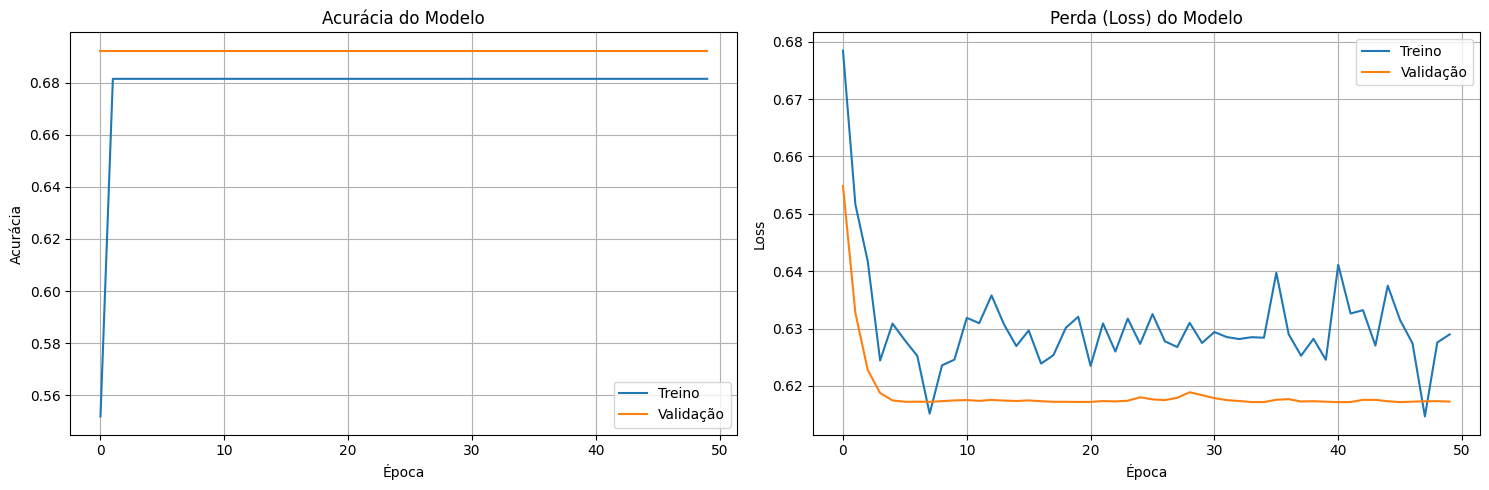

In [14]:
import matplotlib.pyplot as plt

# Criar subplots para acurácia e perda
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de Acurácia
ax1.plot(hist.history['accuracy'], label='Treino')
ax1.plot(hist.history['val_accuracy'], label='Validação')
ax1.set_title('Acurácia do Modelo')
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.legend()
ax1.grid(True)

# Gráfico de Perda (Loss)
ax2.plot(hist.history['loss'], label='Treino')
ax2.plot(hist.history['val_loss'], label='Validação')
ax2.set_title('Perda do Modelo')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [18]:
import time
from sklearn.metrics import accuracy_score

# Carregar os melhores pesos salvos durante o treinamento
model.load_weights('model.weights.best.keras')

# Medir tempo de processamento e realizar predições
start_time = time.time()
y_pred_probs = model.predict(test_dataset)
end_time = time.time()

inference_time = end_time - start_time
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Calcular acurácia
final_accuracy = accuracy_score(test_labels, y_pred)

print(f'Acurácia Final: {final_accuracy:.4f}')
print(f'Tempo de Processamento (Inferência): {inference_time:.2f} segundos')

2/2 ━━━━━━━━━━━━━━━━━━━━ 34s 19s/step
Acurácia Final: 0.6923
Tempo de Processamento (Inferência): 40.96 segundos
